# Rtrees, spatial joins, and policing

## Introduction

This is a dive into RTree -

> Rtree ... provides a number of advanced spatial indexing features for the spatially curious Python user.
>

I look at performing spatial queries, in the context of Queensland Police Station locations [https://www.data.qld.gov.au/dataset/qps-police-stations]


-----------------
## Implementation

### Magics
`lab_black` provides contistent Pytrhon formattinhg, `watermatk`  provides reproducability data

In [1]:
%load_ext lab_black

In [2]:
%load_ext watermark

## Imports

I use `shapely` for some low-level geometric operations

In [3]:
import pandas as pd
import numpy as np

import geopandas as gpd
import geodatasets as gds

import rtree

import matplotlib.pyplot as plt

from shapely.geometry import Point, box

------------------
## Data Load

### Police Stations

We get the police station data into a Pandas DataFrame

In [4]:
URL = "C:\\Data\\Geospatial Data Science Essentials\\data\\QPS_STATIONS.csv"

qps = pd.read_csv(URL)

## Data Exploration

Examine first few rows

In [5]:
qps.head()

,Name,Latitude,Longitude
0,ACACIA RIDGE STATION,-27.588198,153.026536
1,ADAVALE STATION,-25.910819,144.597491
2,AGNES WATER STATION,-24.212576,151.907981
3,ALBANY CREEK STATION,-27.344526,152.965198
4,ALLORA STATION,-28.035288,151.984592


Plot the data - quick and easy  (yep, looks like Queensland)

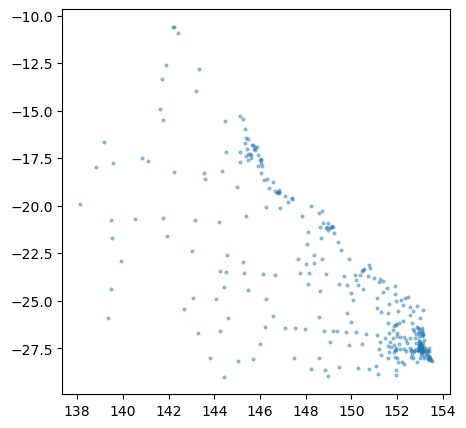

In [6]:
fig, ax = plt.subplots(
    figsize=(5, 5),
)

ax.plot(
    qps["Longitude"],
    qps["Latitude"],
    linewidth=0,
    marker="o",
    markersize=2,
    alpha=0.4,
)

### Coastline

Now I get a coastline.  The Australian Bureau of Statistics has an excellent download-able dataset of state borders

In [7]:
url = gds.data["abs"]["australia_states_territories"]["url"]
gdf = gpd.read_file(url)
gdf.head()

,STE_CODE21,STE_NAME21,CHG_FLAG21,CHG_LBL21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,1,New South Wales,0,No change,AUS,Australia,8.007977e+05,http://linked.data.gov.au/dataset/asgsed3/STE/1,"MULTIPOLYGON (((159.06230 -31.50886, 159.06218..."
1,2,Victoria,0,No change,AUS,Australia,2.274962e+05,http://linked.data.gov.au/dataset/asgsed3/STE/2,"MULTIPOLYGON (((146.29286 -39.15778, 146.29341..."
2,3,Queensland,0,No change,AUS,Australia,1.730171e+06,http://linked.data.gov.au/dataset/asgsed3/STE/3,"MULTIPOLYGON (((142.53140 -10.68301, 142.53072..."
3,4,South Australia,0,No change,AUS,Australia,9.842314e+05,http://linked.data.gov.au/dataset/asgsed3/STE/4,"MULTIPOLYGON (((140.66025 -38.06256, 140.66006..."
4,5,Western Australia,0,No change,AUS,Australia,2.526632e+06,http://linked.data.gov.au/dataset/asgsed3/STE/5,"MULTIPOLYGON (((117.86953 -35.19108, 117.86961..."


Plot the Queensland border

<Axes: >

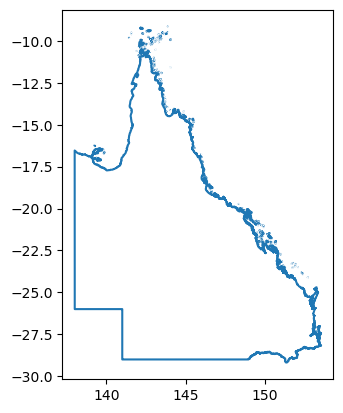

In [8]:
gdf[gdf["STE_CODE21"] == "3"].boundary.plot()

Combine the two plots

<Axes: >

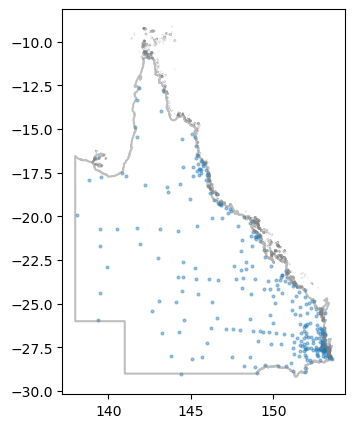

In [9]:
fig, ax = plt.subplots(
    figsize=(5, 5),
)

ax.plot(
    qps["Longitude"],
    qps["Latitude"],
    linewidth=0,
    marker="o",
    markersize=2,
    alpha=0.4,
)
gdf[gdf["STE_CODE21"] == "3"].boundary.plot(
    ax=ax,
    color="gray",
    alpha=0.5,
)

--------------------------

## Rtree 

### Create index

I now create a `Rtree` index, and add all the police station points into the index, associated with the index into the qps DataFrame 

In [10]:
idx = rtree.index.Index()

Add all QPS locations into the index.  I create  `Point` object for each station

In [11]:
for i in range(len(qps)):
    p = Point(
        qps.iloc[i]["Longitude"], qps.iloc[i]["Latitude"]
    )
    idx.insert(i, p.bounds)
# end for

### Query index

Suppose we say every station north of 15 degrees South is a Northern Station, and we want to list their names

Create query box that covers North Queensland

In [12]:
qbox = box(140, -15, 150, -10)
qbox.bounds

(140.0, -15.0, 150.0, -10.0)

Create a generator that returns the DataFrame index of each station in the query box

In [13]:
nth_qld = idx.intersection(qbox.bounds)

Print the names and locations of each northern station.  Note we have to turn the generator into a list

In [14]:
for i in list(idx.intersection(qbox.bounds)):
    print(
        f'{(qps.iloc[i]["Name"]+','):30} at {qps.iloc[i]["Longitude"]:4.1f}E, {abs(qps.iloc[i]["Latitude"]):4.1f}S'
    )
# end for

PORMPURAAW STATION,            at 141.6E, 14.9S
COEN STATION,                  at 143.2E, 13.9S
AURUKUN STATION,               at 141.7E, 13.4S
LOCKHART RIVER STATION,        at 143.3E, 12.8S
BAMAGA STATION,                at 142.4E, 10.9S
HORN ISLAND STATION,           at 142.2E, 10.6S
THURSDAY ISLAND STATION,       at 142.2E, 10.6S
WEIPA STATION,                 at 141.9E, 12.6S


### Plot query results

The sequence is:
* draw all stations,
* draw the query box,
*  draw with a new symbol at the selected stations,
*  draw the coast line,
*  draw a legend

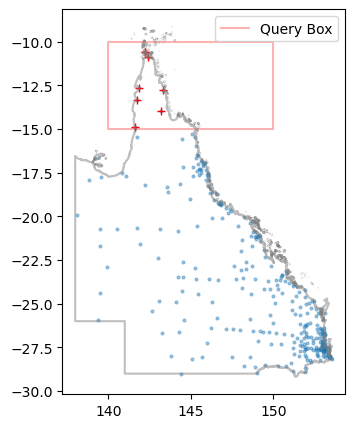

In [15]:
fig, ax = plt.subplots(
    figsize=(5, 5),
)

# plot all stations
ax.plot(
    qps["Longitude"],
    qps["Latitude"],
    linewidth=0,
    marker="o",
    markersize=2,
    alpha=0.4,
)

# Plot the query bounding box
x, y = qbox.exterior.xy
ax.plot(
    x,
    y,
    "r-",
    label="Query Box",
    alpha=0.3,
)

#  plot the selected stations in different color
for i in list(idx.intersection(qbox.bounds)):
    ax.plot(
        [qps.iloc[i]["Longitude"]],
        [qps.iloc[i]["Latitude"]],
        color="red",
        marker="+",
    )
# end for

# plot coastline
gdf[gdf["STE_CODE21"] == "3"].boundary.plot(
    ax=ax,
    color="gray",
    alpha=0.5,
)

# draw a legend
ax.legend()

### Detailed plot

To look at the whole of north Queenland, I plot all stations above 20 degrees South.  Again, I use Rtree query to select these stations.

I cheat a bit to get the text names of stations to not overlap

Horn


<Axes: >

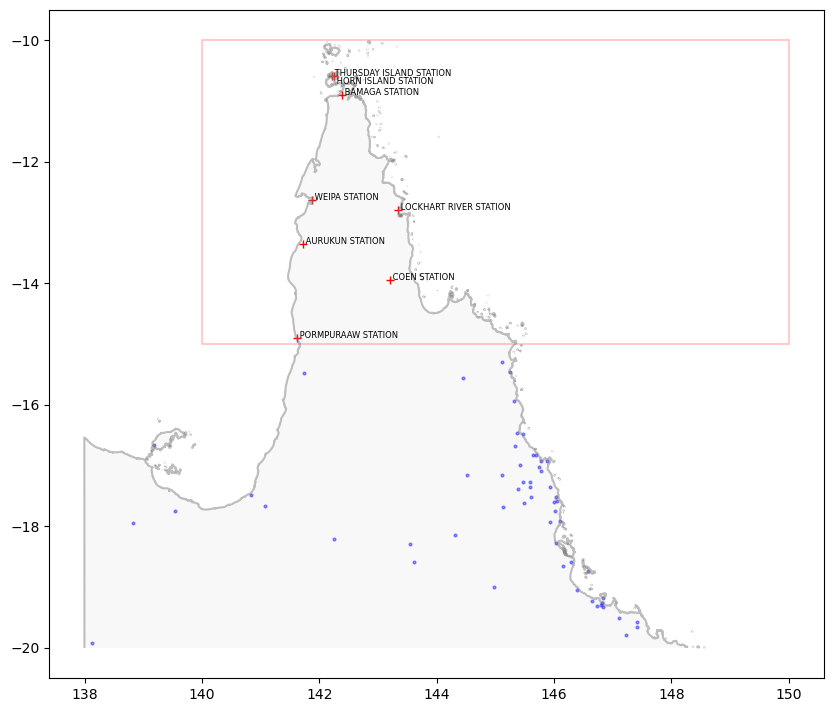

In [16]:
fig, ax = plt.subplots(
    figsize=(10, 10),
)


# Plot the query bounding box
x, y = qbox.exterior.xy
ax.plot(
    x,
    y,
    "r-",
    label="Query Box",
    alpha=0.2,
)

# draw selected stations in red, adjusting text location where needed
for i in list(idx.intersection(qbox.bounds)):
    ax.plot(
        [qps.iloc[i]["Longitude"]],
        [qps.iloc[i]["Latitude"]],
        color="red",
        marker="+",
    )
    if qps.iloc[i]["Name"].startswith("HORN"):
        print("Horn")
        ax.text(
            qps.iloc[i]["Longitude"],
            qps.iloc[i]["Latitude"],
            " " + qps.iloc[i]["Name"],
            fontsize=6,
            verticalalignment="top",
        )
    else:
        ax.text(
            qps.iloc[i]["Longitude"],
            qps.iloc[i]["Latitude"],
            " " + qps.iloc[i]["Name"],
            fontsize=6,
        )
    # end if
# end for

# select stations between 15 and 20 degrees South, and plot with blue marker
cbox = box(130, -20, 160, -15)
for i in list(idx.intersection(cbox.bounds)):
    ax.plot(
        [qps.iloc[i]["Longitude"]],
        [qps.iloc[i]["Latitude"]],
        linewidth=0,
        marker="o",
        markersize=2,
        alpha=0.4,
        color="blue",
    )
# end for

# plot coastline
gdf[gdf["STE_CODE21"] == "3"].boundary.clip(
    [130, -20, 160, -10]
).plot(
    ax=ax,
    color="gray",
    alpha=0.5,
)

# fill land very light gray
gdf[gdf["STE_CODE21"] == "3"].clip(
    [130, -20, 160, -10]
).plot(
    ax=ax,
    color="gray",
    alpha=0.05,
    linewidth=0.5,
)

-----------------------------------

## Island stations

In this next example, I use  a `geopandas` spatial join to get all police stations NOT on the mainland 

Get the Queensland state borders

In [17]:
qld = gdf[gdf["STE_CODE21"] == "3"].copy()

Explode the GeoDataFrame to turn a single MultiPolygon row into multiple rows of single Polygons

In [18]:
qld = qld.explode(ignore_index=True).reset_index().copy()

Create a new column holding area of each Polygon  (I can ignore the warning message, as I am not interest in accuracy, justing finding the largest Polygon: i.e. the mainland)

In [19]:
qld["area"] = qld.area

C:\Users\donrc\AppData\Local\Temp\ipykernel_20148\1836405588.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  qld["area"] = qld.area


Get the mainland polygon by reverse sorting the Polygons by area, and choosing the first row

In [20]:
qld_poly = qld.sort_values(
    by="area",
    ascending=False,
).iloc[0:1]["geometry"]

Get `shapely`  to plot our mainland just as a check

In [21]:
qld_poly.reset_index(drop=True)[0]

Create the GeoDataFrame corresponding to our mainland

In [22]:
mainland_df = qld.sort_values(
    by="area",
    ascending=False,
).iloc[0:1]

Create a GeoDataFrame holding police station locations and names

In [23]:
qps_gdf = gpd.GeoDataFrame(
    qps,
    geometry=gpd.points_from_xy(
        qps["Longitude"], qps["Latitude"]
    ),
)

Set the Coordinate Reference System (CRS) of each GeoDataFrame to Plate Carree projection

In [24]:
qps_gdf = qps_gdf.set_crs("epsg:4326").copy()
mainland_df = mainland_df.to_crs("epsg:4326").copy()

print(mainland_df.crs)

epsg:4326


Get  only those police stations that are located with the mainland

In [25]:
mainland = gpd.sjoin(
    qps_gdf, mainland_df, how="inner", predicate="within"
)

We haved 10 police stations that are not on the mainland

In [26]:
len(mainland), len(qps_gdf), len(qps)

(325, 335, 335)

Get the set of non-mainland stations

In [27]:
set(qps_gdf.index) - set(mainland.index)

{34, 92, 109, 135, 179, 180, 206, 236, 263, 294}

Get a GeoDataFrame of island (non-mainland) police stations

In [28]:
island_gdf = qps_gdf.iloc[
    list(set(qps_gdf.index) - set(mainland.index))
].copy()

----------------------

## Validation and visualization

As a check, we find the list of police stations with "ISLAND" in their name, and we do indeed have all of these

In [29]:
qps[qps["Name"].str.contains("ISLAND")]

,Name,Latitude,Longitude
34,BRIBIE ISLAND STATION,-27.064456,153.153480
135,HORN ISLAND STATION,-10.595022,142.249562
179,MACLEAY ISLAND STATION,-27.617607,153.360666
180,MAGNETIC ISLAND STATION,-19.177207,146.839683
206,MORNINGTON ISLAND STATION,-16.665608,139.181799
236,PALM ISLAND STATION,-18.734375,146.578554
263,RUSSELL ISLAND STATION,-27.648466,153.382083
294,THURSDAY ISLAND STATION,-10.586986,142.211644


Plot the results

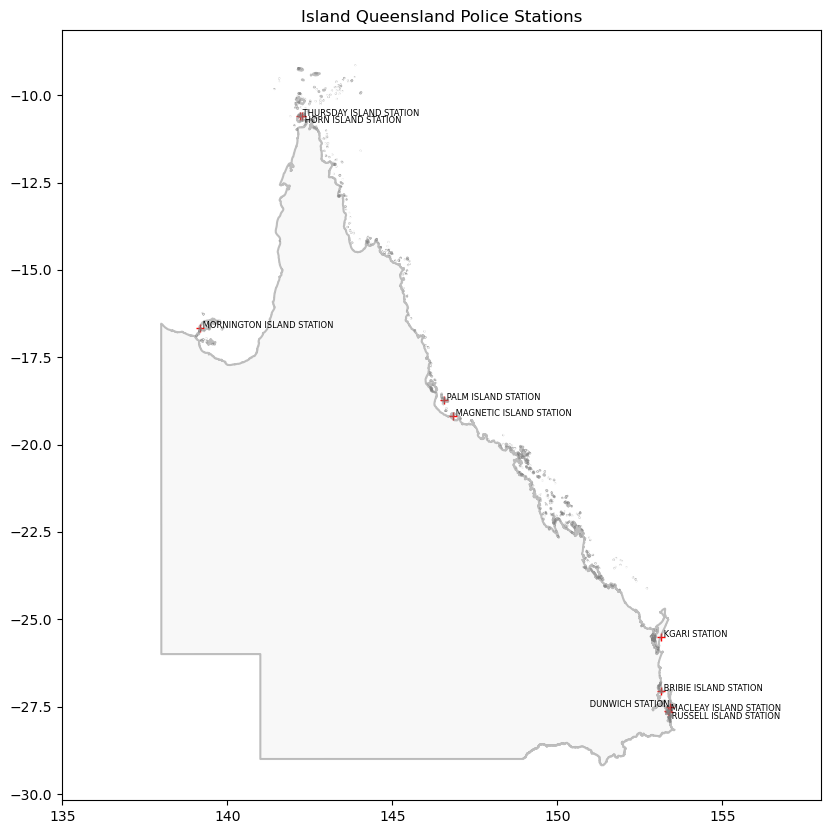

In [30]:
fig, ax = plt.subplots(
    figsize=(10, 10),
)


# plot the location of each island station
for i in island_gdf.index:
    ax.plot(
        [qps.iloc[i]["Longitude"]],
        [qps.iloc[i]["Latitude"]],
        color="red",
        marker="+",
    )

    # draw text names adjusting location as needed
    if qps.iloc[i]["Name"].startswith("HORN") or qps.iloc[
        i
    ]["Name"].startswith("RUSSELL"):
        ax.text(
            qps.iloc[i]["Longitude"],
            qps.iloc[i]["Latitude"],
            " " + qps.iloc[i]["Name"],
            fontsize=6,
            verticalalignment="top",
        )
    elif qps.iloc[i]["Name"].startswith("DUNWICH"):
        ax.text(
            qps.iloc[i]["Longitude"],
            qps.iloc[i]["Latitude"],
            " " + qps.iloc[i]["Name"],
            fontsize=6,
            horizontalalignment="right",
        )
    else:
        ax.text(
            qps.iloc[i]["Longitude"],
            qps.iloc[i]["Latitude"],
            " " + qps.iloc[i]["Name"],
            fontsize=6,
        )
    # end if
# end for

# draw coastline
gdf[gdf["STE_CODE21"] == "3"].boundary.plot(
    ax=ax,
    color="gray",
    alpha=0.5,
)

# fill mainland with light gray
gdf[gdf["STE_CODE21"] == "3"].plot(
    ax=ax,
    color="gray",
    alpha=0.05,
    linewidth=0.5,
)

# adjust plot frame so names don't projcet past frame
ax.set_xlim(135, 158)
_ = ax.set_title("Island Queensland Police Stations")

-------------------------
## Rtree and closeness

We now find at the ten closest stations to my home

#### Query

In [31]:
home = Point(153.0814362, -26.5269542)

In [32]:
home.xy

(array('d', [153.0814362]), array('d', [-26.5269542]))

In [33]:
close_10 = idx.nearest(home.bounds, num_results=10)

#### Print

In [34]:
for i in list(close_10):
    print(
        f'{(qps.iloc[i]["Name"]+','):30} at {qps.iloc[i]["Longitude"]:4.1f}E, {abs(qps.iloc[i]["Latitude"]):4.1f}S'
    )
# end for

COOLUM STATION,                at 153.1E, 26.5S
NOOSA HEADS STATION,           at 153.1E, 26.4S
MAROOCHYDORE STATION,          at 153.1E, 26.7S
EUMUNDI STATION,               at 153.0E, 26.5S
NAMBOUR STATION,               at 153.0E, 26.6S
SIPPY DOWNS STATION,           at 153.1E, 26.7S
COOROY STATION,                at 152.9E, 26.4S
PALMWOODS STATION,             at 153.0E, 26.7S
KAWANA WATERS STATION,         at 153.1E, 26.7S
CALOUNDRA STATION,             at 153.1E, 26.8S


#### Plot

Get the bounds of the geometries of the set of selected points

In [35]:
bounds = qps_gdf.iloc[
    list(idx.nearest(home.bounds, num_results=10))
]["geometry"].total_bounds
bounds

array([152.910141, -26.801975, 153.128638, -26.40769 ])

Draw home marker, station markers and names, coastline and land.

One hack is that because I draw each marker in a `for` loop, I can't supply a legend label on each plot call: if I do I get 10 labels in the legend. So I draw a dummy station marker underneath my home marker

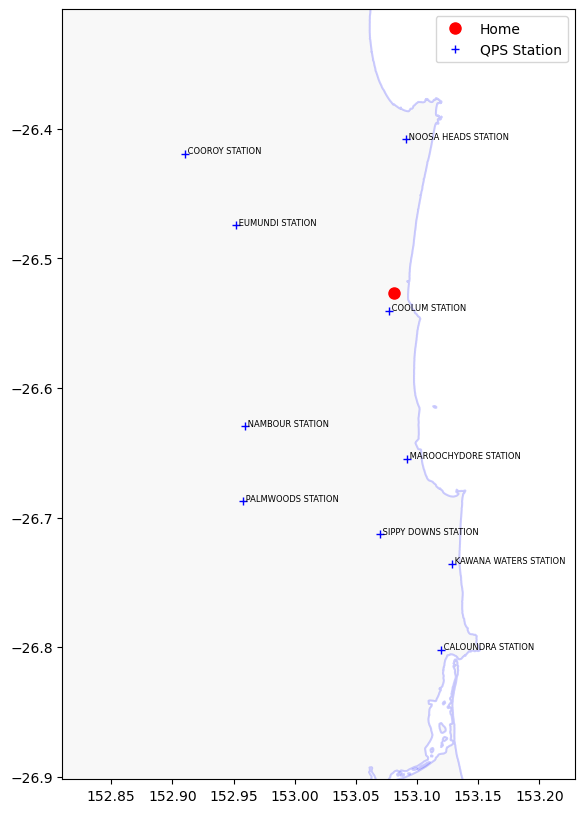

In [36]:
fig, ax = plt.subplots(
    figsize=(10, 10),
)

# plot home point
ax.plot(
    [home.xy[0][0]],
    [home.xy[1][0]],
    marker="o",
    markersize=8,
    color="red",
    label="Home",
    linewidth=0,
    zorder=2,
)

# plot a spurious point below home marker, for legend label
ax.plot(
    [home.xy[0][0]],
    [home.xy[1][0]],
    marker="+",
    color="blue",
    label="QPS Station",
    linewidth=0,
    zorder=1,
)


# extend limits of plot to allow space for names
ax.set_xlim(bounds[0] - 0.1, bounds[2] + 0.1)
ax.set_ylim(bounds[1] - 0.1, bounds[3] + 0.1)

# plot the location and name of each island station
for i in list(idx.nearest(home.bounds, num_results=10)):
    ax.plot(
        [qps.iloc[i]["Longitude"]],
        [qps.iloc[i]["Latitude"]],
        color="blue",
        marker="+",
    )

    ax.text(
        qps.iloc[i]["Longitude"],
        qps.iloc[i]["Latitude"],
        " " + qps.iloc[i]["Name"],
        fontsize=6,
    )
# end for

# draw coastline
gdf[gdf["STE_CODE21"] == "3"].boundary.plot(
    ax=ax,
    color="blue",
    alpha=0.2,
)

# fill mainland with light gray
gdf[gdf["STE_CODE21"] == "3"].plot(
    ax=ax,
    color="gray",
    alpha=0.05,
    linewidth=0.5,
)

ax.legend()

---------------------

## Reproducability

In [37]:
%watermark

Last updated: 2025-05-25T15:39:20.132642+10:00

Python implementation: CPython
Python version       : 3.12.7
IPython version      : 8.29.0

Compiler    : MSC v.1941 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 170 Stepping 4, GenuineIntel
CPU cores   : 22
Architecture: 64bit



In [38]:
%watermark -co  -iv -v -h

Python implementation: CPython
Python version       : 3.12.7
IPython version      : 8.29.0

conda environment: geospatial

Hostname: INSPIRON16

geopandas  : 0.14.4
rtree      : 1.3.0
pandas     : 2.2.3
geodatasets: 2024.8.0
shapely    : 2.0.6
numpy      : 1.26.4
matplotlib : 3.8.4

